<bound method DataFrame.count of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.

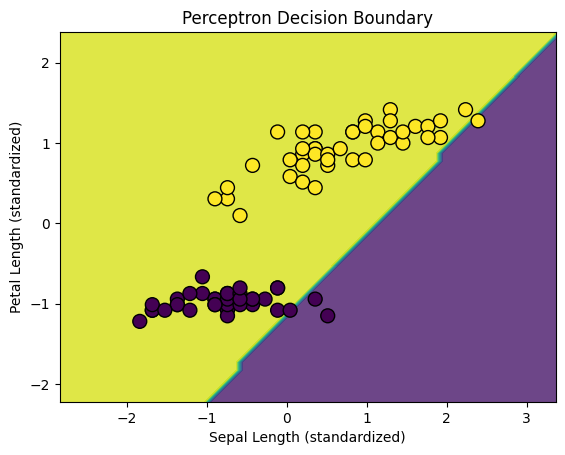

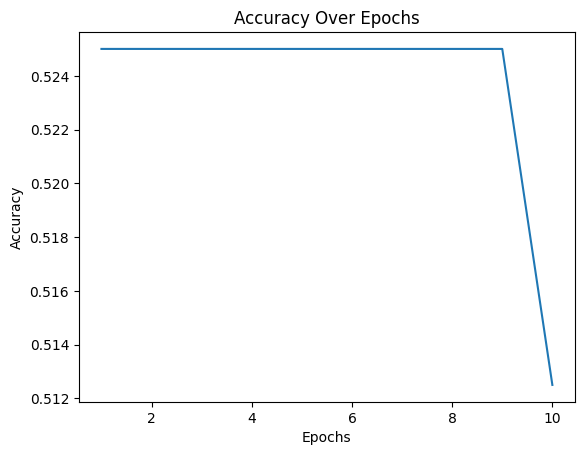


Training with learning rate=0.001 and epochs=50
Test Accuracy: 0.4000


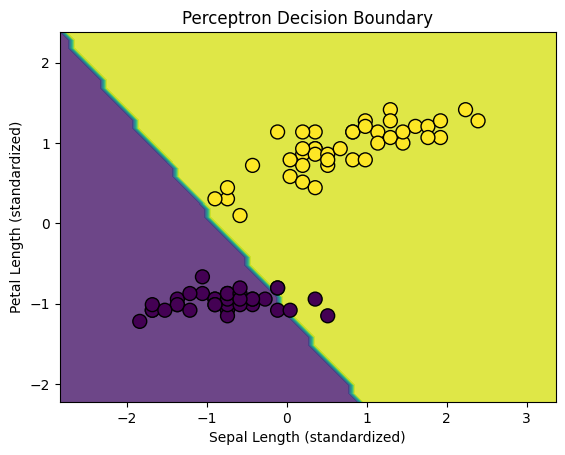

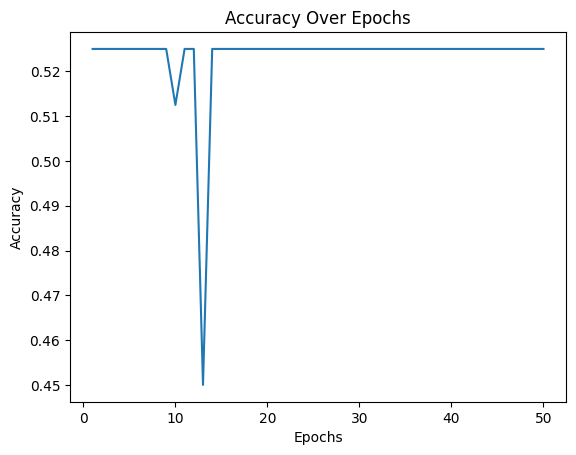


Training with learning rate=0.001 and epochs=100
Test Accuracy: 0.4000


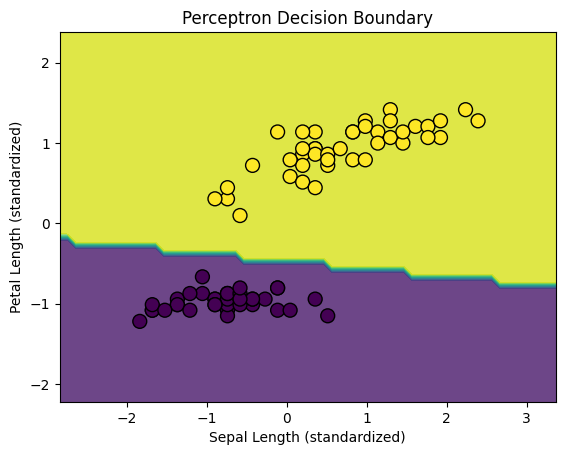

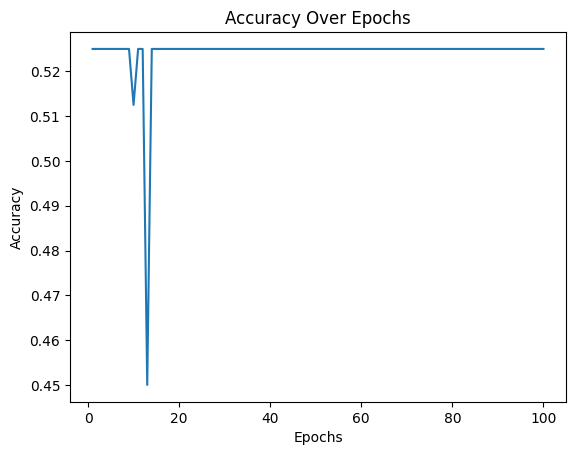


Training with learning rate=0.001 and epochs=200
Test Accuracy: 0.4000


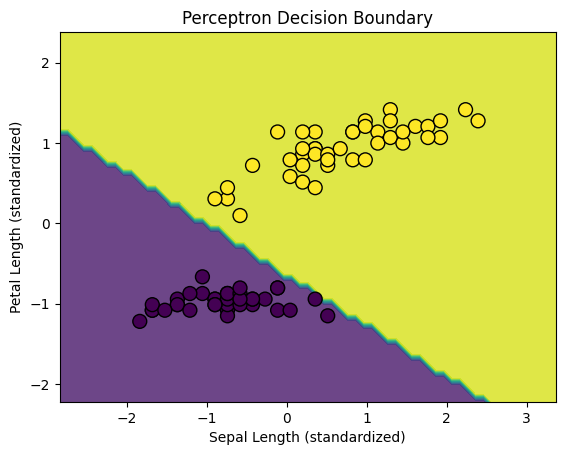

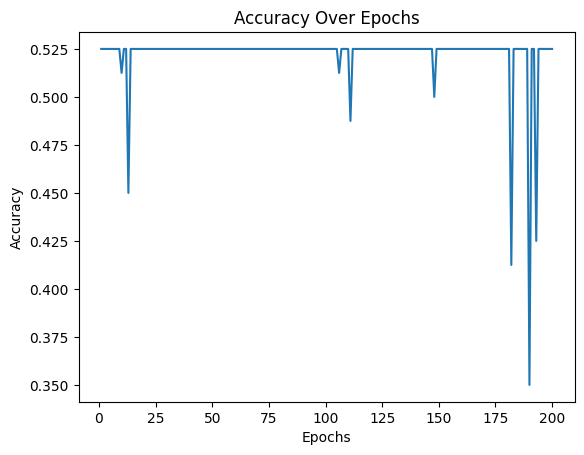


Training with learning rate=0.001 and epochs=1000
Test Accuracy: 0.4000


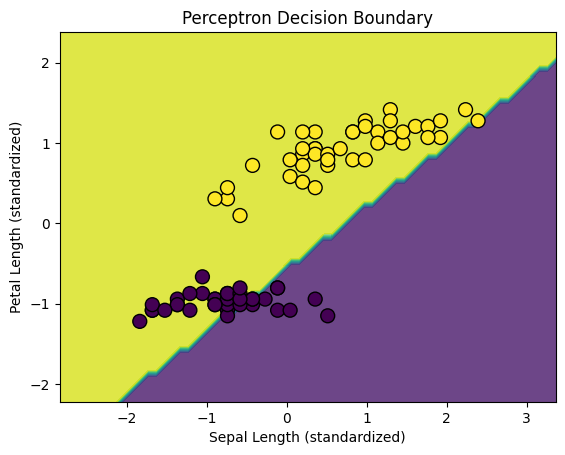

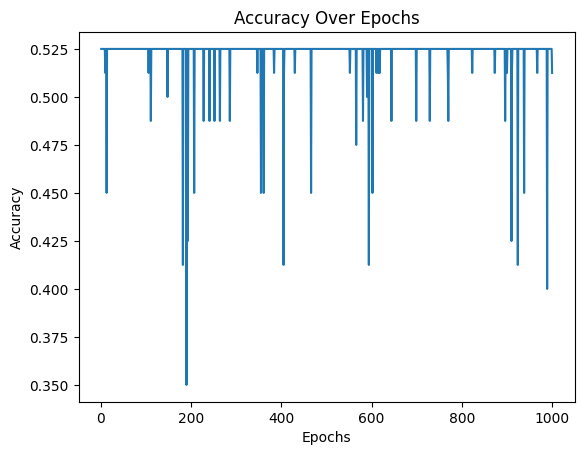


Training with learning rate=0.01 and epochs=10
Test Accuracy: 0.4000


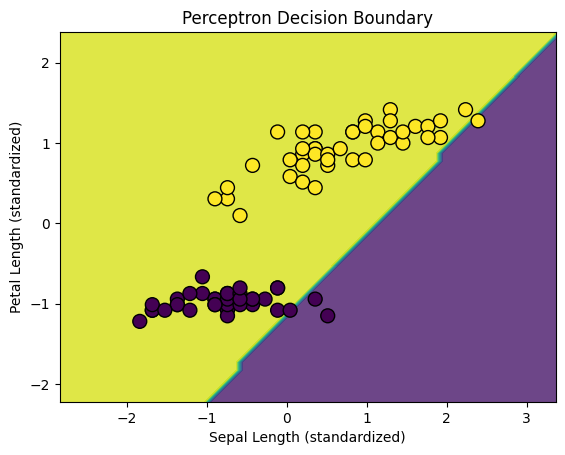

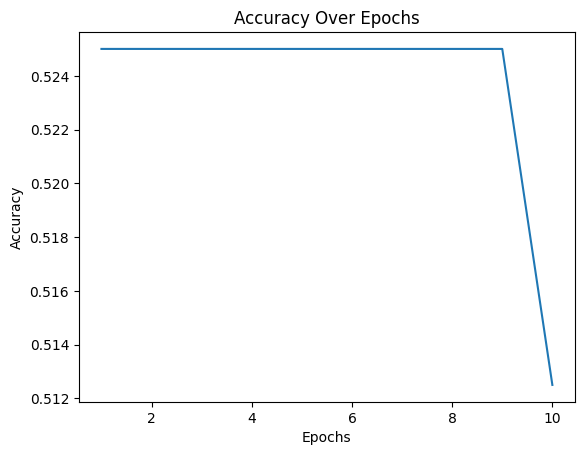


Training with learning rate=0.01 and epochs=50
Test Accuracy: 0.4000


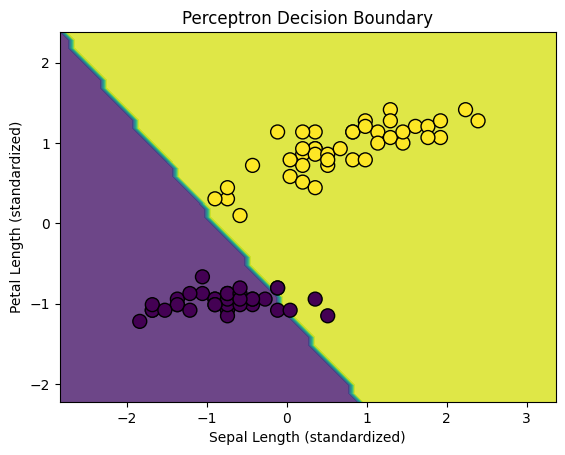

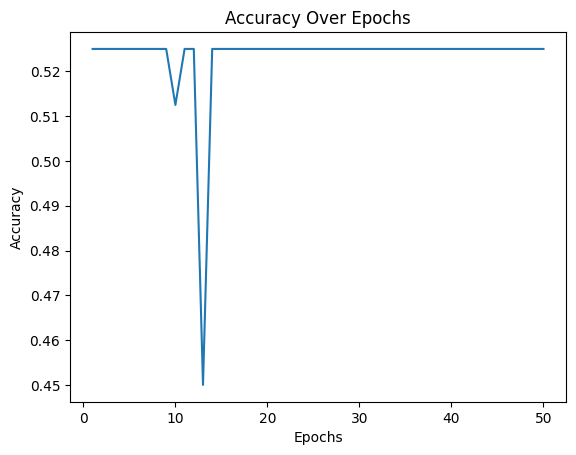


Training with learning rate=0.01 and epochs=100
Test Accuracy: 0.4000


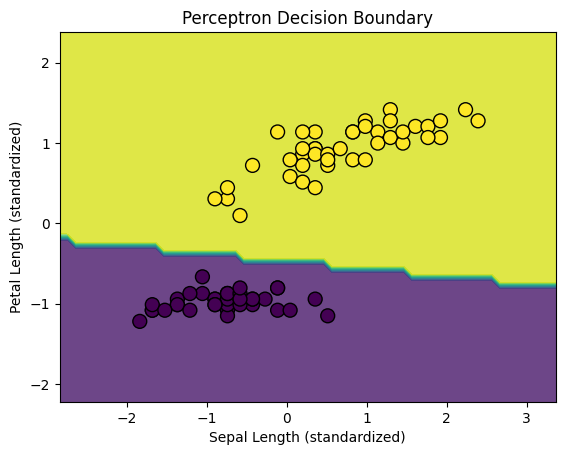

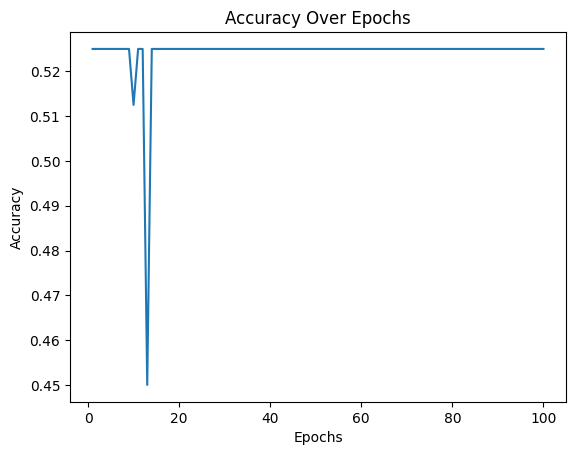


Training with learning rate=0.01 and epochs=200
Test Accuracy: 0.4000


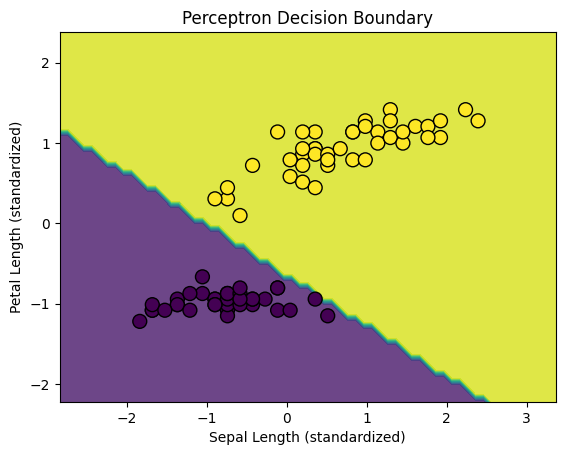

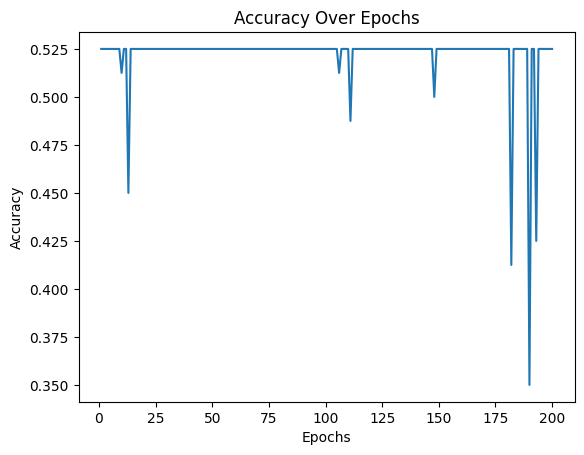


Training with learning rate=0.01 and epochs=1000
Test Accuracy: 0.4000


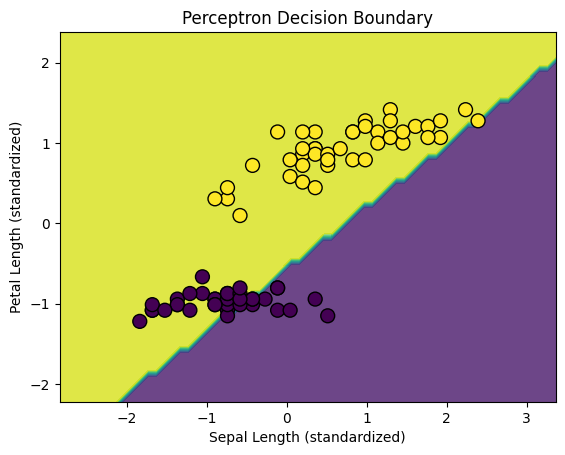

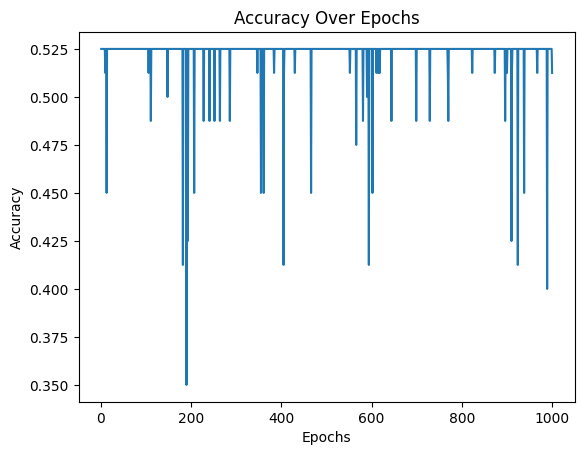


Training with learning rate=0.1 and epochs=10
Test Accuracy: 0.4000


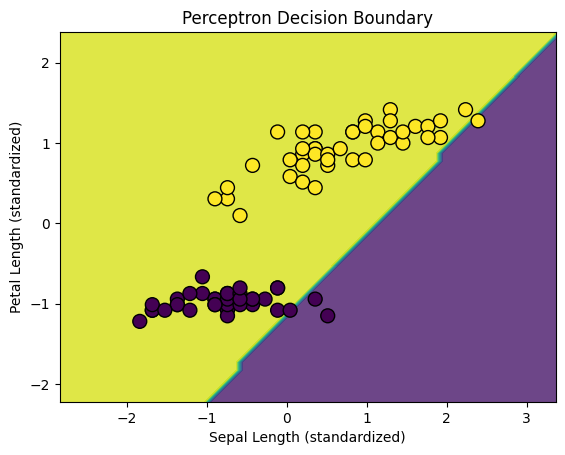

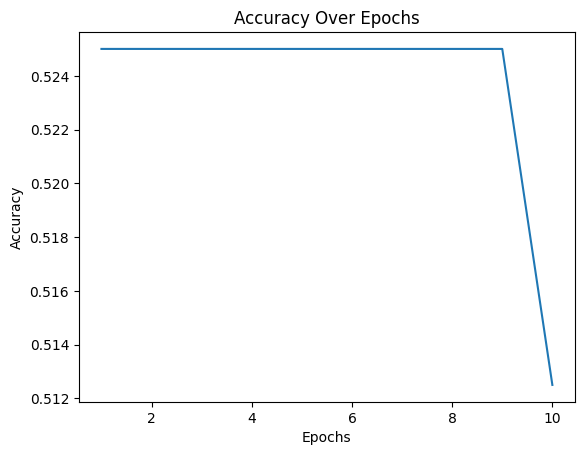


Training with learning rate=0.1 and epochs=50
Test Accuracy: 0.4000


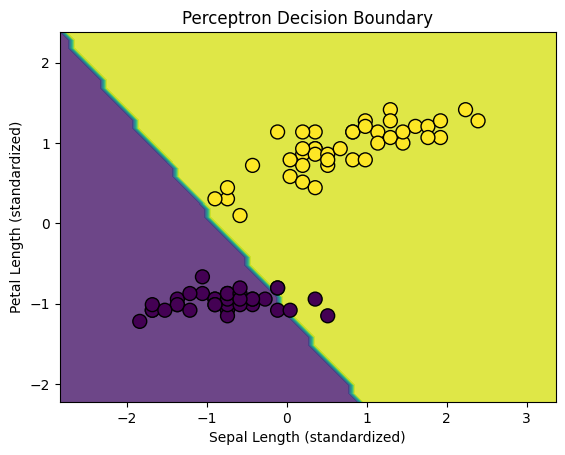

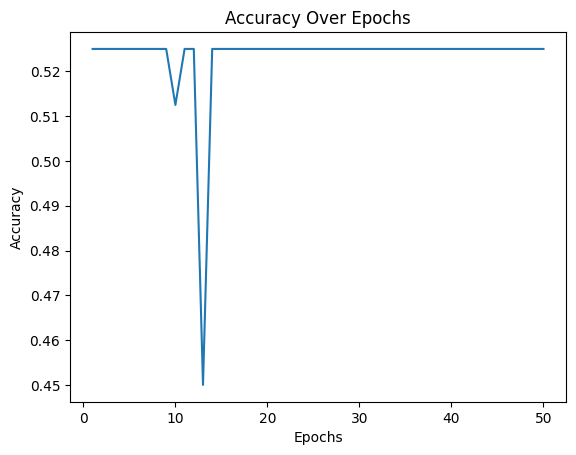


Training with learning rate=0.1 and epochs=100
Test Accuracy: 0.4000


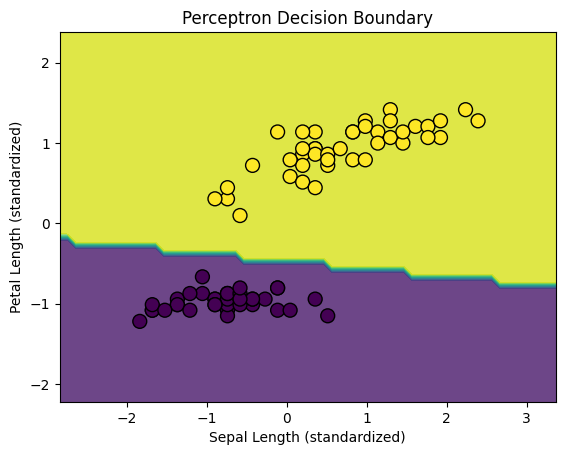

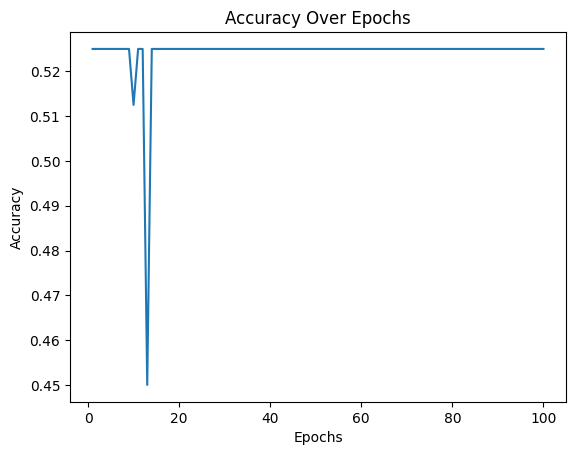


Training with learning rate=0.1 and epochs=200
Test Accuracy: 0.4000


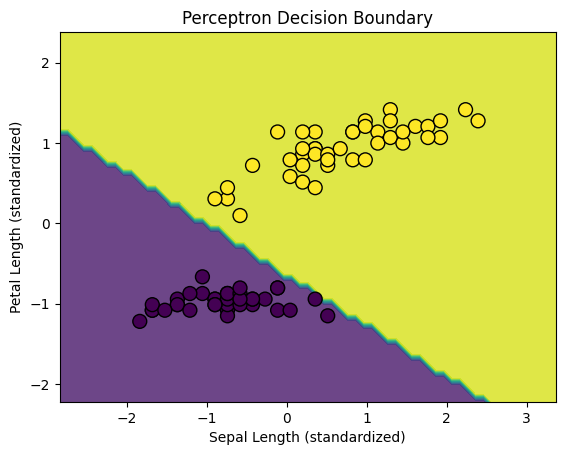

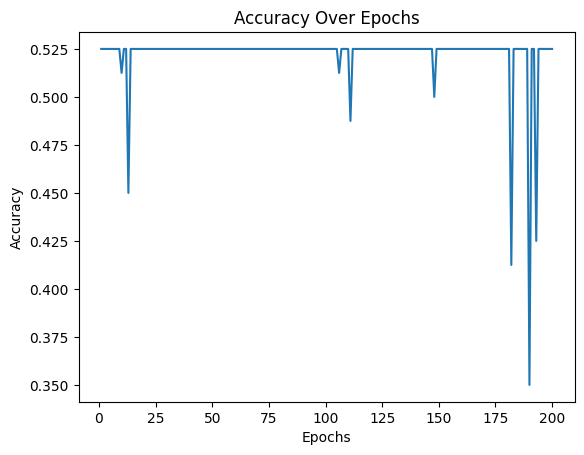


Training with learning rate=0.1 and epochs=1000
Test Accuracy: 0.4000


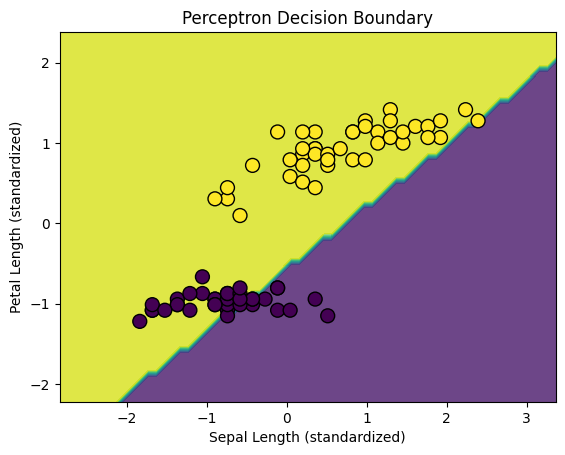

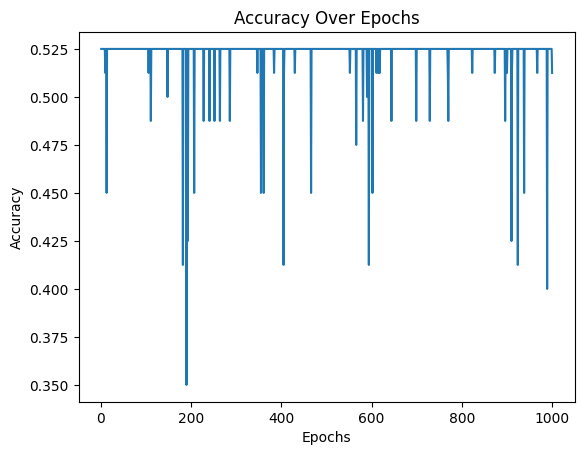


Training with learning rate=0.5 and epochs=10
Test Accuracy: 0.4000


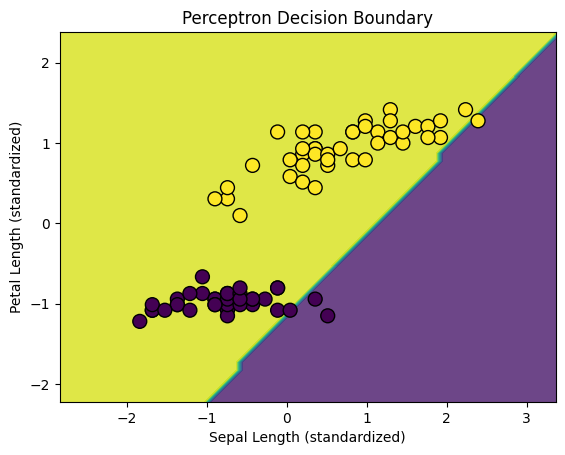

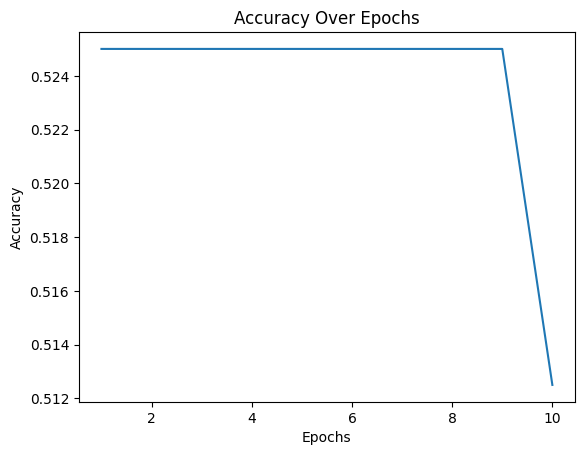


Training with learning rate=0.5 and epochs=50
Test Accuracy: 0.4000


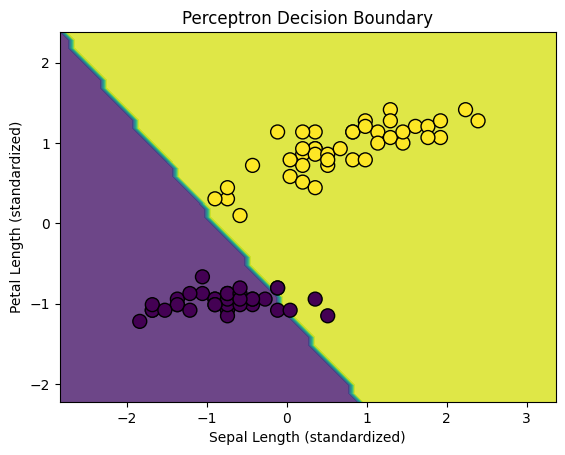

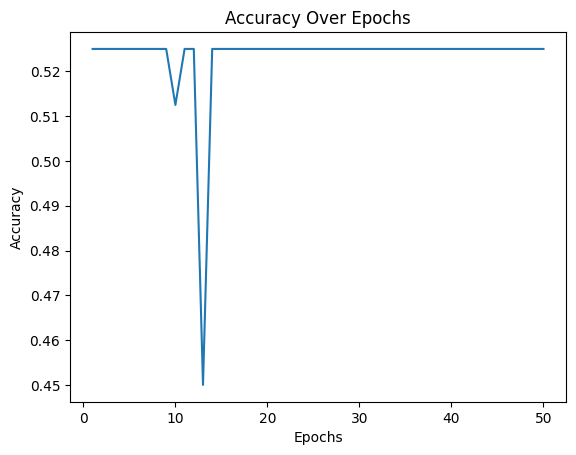


Training with learning rate=0.5 and epochs=100
Test Accuracy: 0.4000


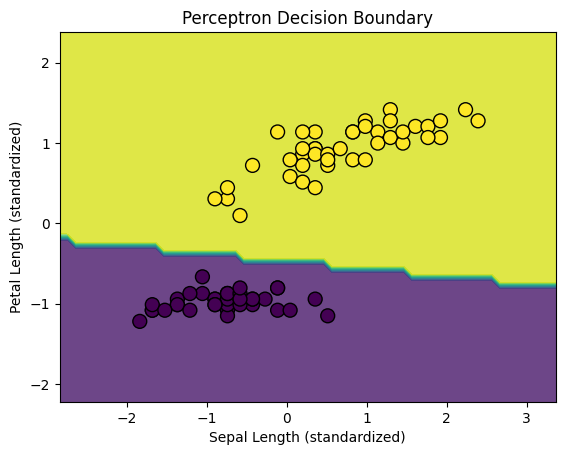

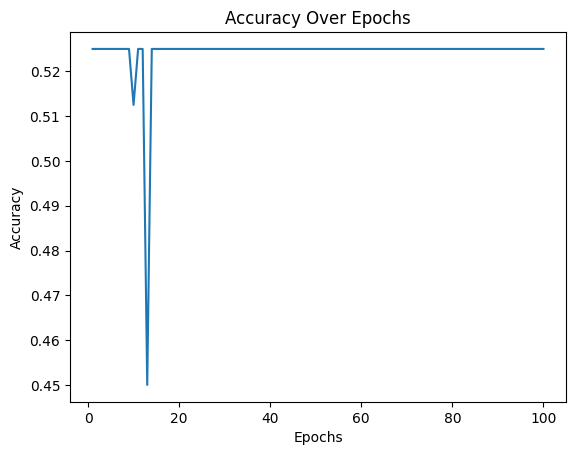


Training with learning rate=0.5 and epochs=200
Test Accuracy: 0.4000


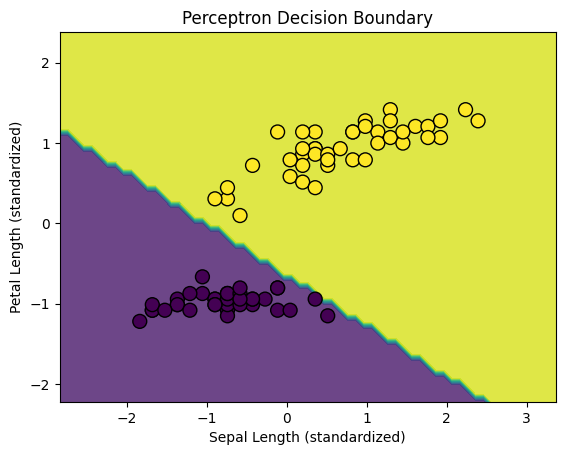

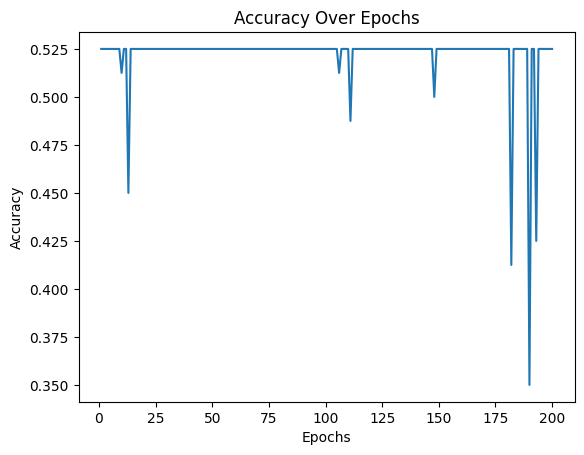


Training with learning rate=0.5 and epochs=1000
Test Accuracy: 0.4000


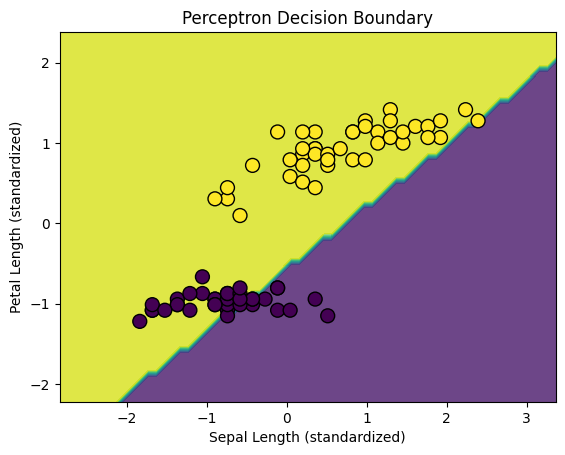

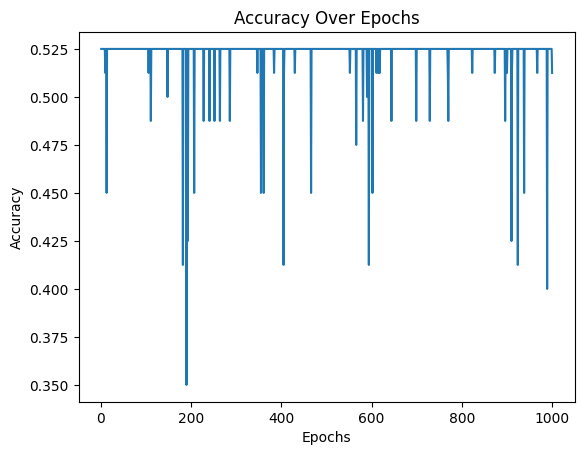


Training with learning rate=0.9 and epochs=10
Test Accuracy: 0.4000


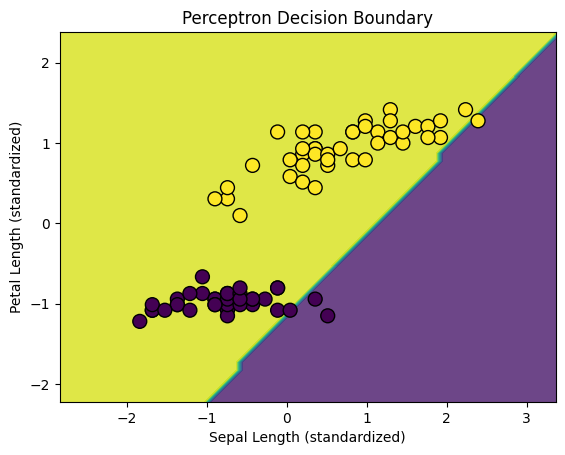

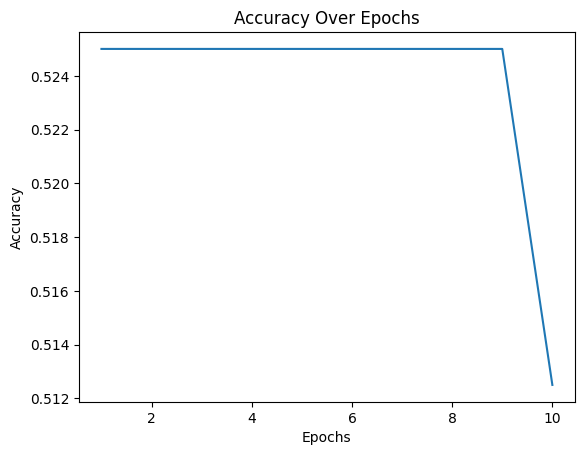


Training with learning rate=0.9 and epochs=50
Test Accuracy: 0.4000


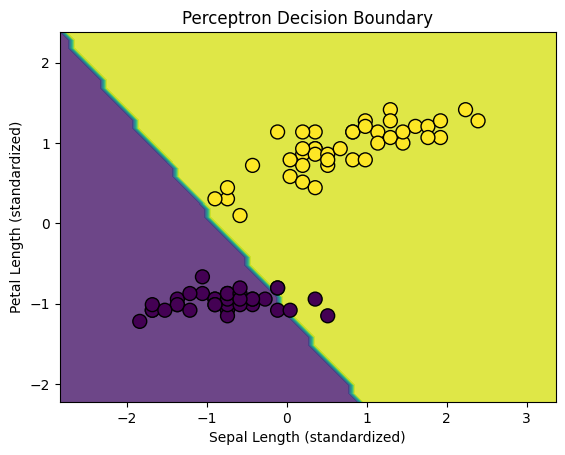

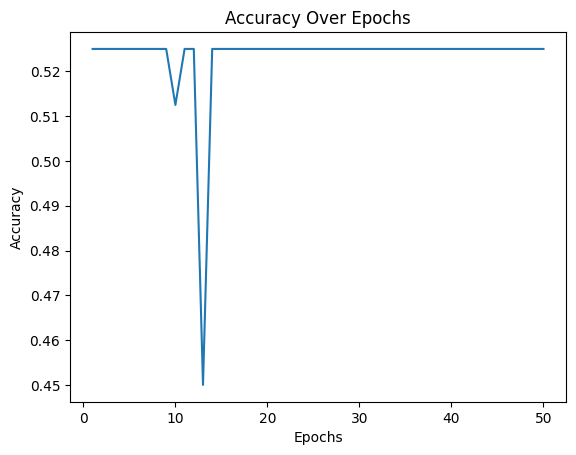


Training with learning rate=0.9 and epochs=100
Test Accuracy: 0.4000


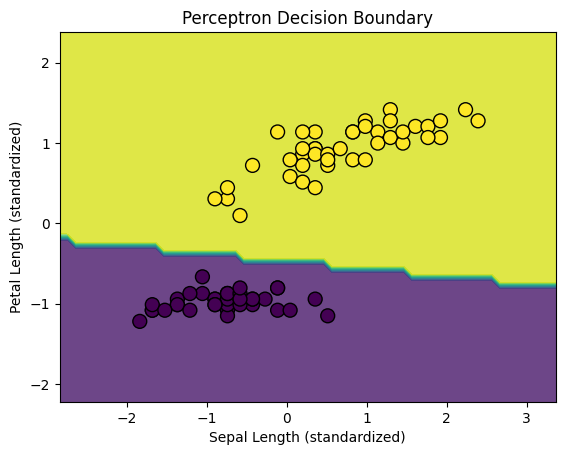

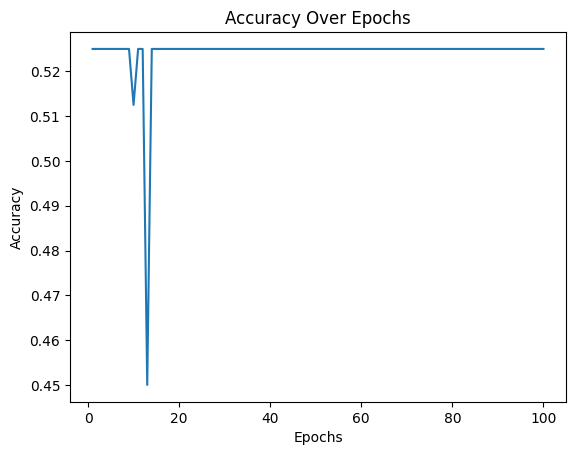


Training with learning rate=0.9 and epochs=200
Test Accuracy: 0.4000


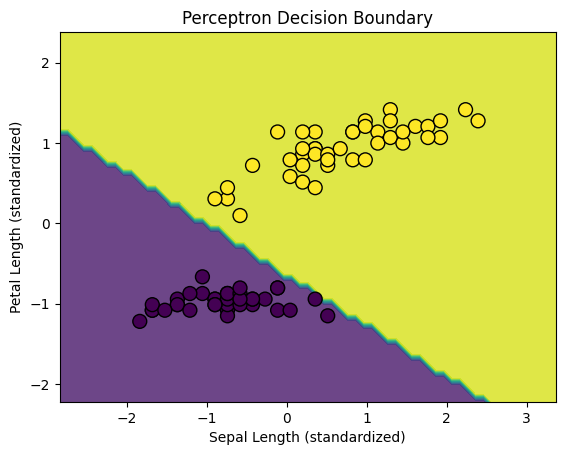

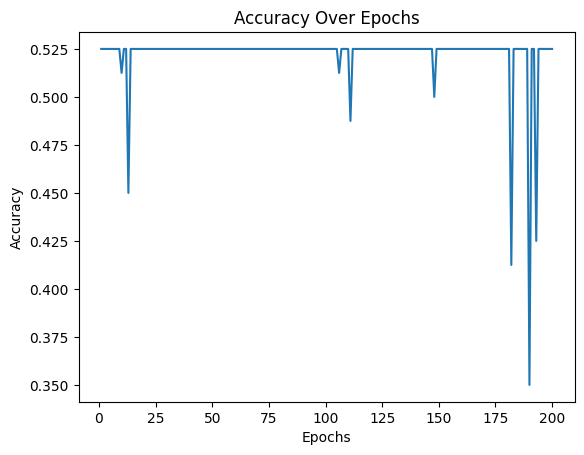


Training with learning rate=0.9 and epochs=1000
Test Accuracy: 0.4000


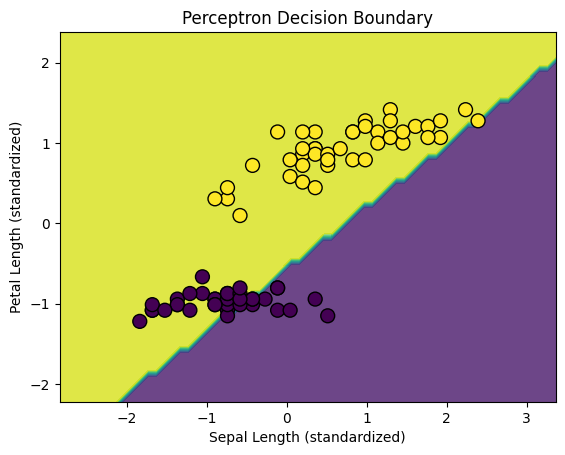

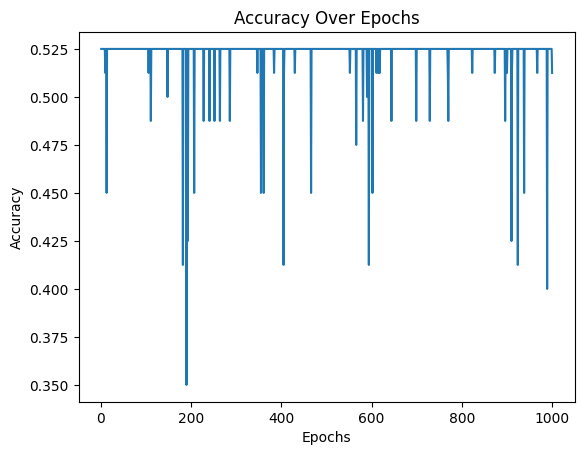

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


def plot_decision_boundary(perceptron, X, y):
    # Define a mesh grid range based on the feature space of the dataset
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    # Predict the classification for each point in the mesh grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = perceptron.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Create the plot
    plt.contourf(xx, yy, Z, alpha=0.8)

    # Plot the actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o", s=100)
    plt.title("Perceptron Decision Boundary")
    plt.xlabel("Sepal Length (standardized)")
    plt.ylabel("Petal Length (standardized)")
    plt.show()


def plot_accuracy_over_epochs(perceptron):
    plt.plot(
        range(1, len(perceptron.accuracy_over_epochs) + 1),
        perceptron.accuracy_over_epochs,
    )
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.show()


# Load the Iris dataset
iris = load_iris()
# Create a DataFrame
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data["target"] = iris.target

print(data.count)

# Filter the dataset for Setosa (class 0) and Versicolor (class 1)
filtered_data = data[data["target"].isin([0, 1])]

# Select features: sepal length and petal length
X = filtered_data[["sepal length (cm)", "petal length (cm)"]]
y = filtered_data["target"]

# Standardize the data
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.2, random_state=42
)

# Display the first few rows of the training data
print("Training features:\n", X_train[:5])
print("Training labels:\n", y_train[:5])

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100, random_state=None):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.random_state = random_state
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Convert y to a NumPy array
        y = np.array(y)
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Ensure reproducibility
        np.random.seed(self.random_state)

        # Tracking accuracy over epochs for visualization
        self.accuracy_over_epochs = []

        # Training loop for given epochs
        for epoch in range(self.epochs):
            # Shuffle the data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X, y = X[indices], y[indices]

            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self._activation(linear_output)

                # Weight update rule
                update = self.learning_rate * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

            # Track accuracy at the end of each epoch
            y_pred_epoch = self.predict(X)
            accuracy = np.mean(y == y_pred_epoch)
            self.accuracy_over_epochs.append(accuracy)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._activation(linear_output)

    def _activation(self, x):
        # Step function: returns 1 if x >= 0, else -1
        return np.where(x >= 0, 1, -1)




# Initialize the Perceptron model
random_state = 42

# Test different learning rates and epochs
learning_rates = [0.001, 0.01, 0.1, 0.5, 0.9]
epoch_values = [10, 50, 100, 200, 1000]

for lr in learning_rates:
    for epochs in epoch_values:
        print(f"\nTraining with learning rate={lr} and epochs={epochs}")
        perceptron = Perceptron(
            learning_rate=lr, epochs=epochs, random_state=random_state
        )
        perceptron.fit(X_train, y_train)

        # Predict on test data
        y_test_pred = perceptron.predict(X_test)
        test_accuracy = np.mean(y_test == y_test_pred)
        print(f"Test Accuracy: {test_accuracy:.4f}")

        # Plot decision boundary for this setting
        plot_decision_boundary(perceptron, X_train, y_train)

        # Plot accuracy over epochs
        plot_accuracy_over_epochs(perceptron)